In [1]:
import csv
import glob
import json
import math
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict, Any

import numpy as np
import soundfile as sf

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import torchaudio
from praatio import textgrid
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor, get_linear_schedule_with_warmup

DATA_MFA_DIR = Path('/home/huy/207177/data/mfa')
CHECKPOINT_ROOT = Path('/home/huy/207177/output/checkpoint')
ALIGNED_DIR = DATA_MFA_DIR / 'aishell_aligned'
LABELS_DIR = DATA_MFA_DIR / 'labels_out'
CORPUS_PAIR_WAV_DIR = DATA_MFA_DIR / 'corpus_pair' / 'wav'
MANIFEST_DIR = DATA_MFA_DIR / 'manifests' / 'AISHELL-1.0'

for p in [LABELS_DIR, MANIFEST_DIR, CHECKPOINT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

FRAME = 0.025

PRETRAINED = 'facebook/wav2vec2-large-960h'
SR = 16000
SEED = 1337
BATCH_SIZE = 1
LR_HEAD = 1e-4
LR_FULL = 1e-5
FREEZE_UPDATES = 5000
TOTAL_UPDATES = 30000
WARMUP_UPDATES = 1000
EVAL_EVERY = 1000
DEV_RATIO = 0.02
MIN_DEV = 500

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('ALIGNED_DIR:', ALIGNED_DIR)
print('LABELS_DIR:', LABELS_DIR)
print('CORPUS_PAIR_WAV_DIR:', CORPUS_PAIR_WAV_DIR)
print('MANIFEST_DIR:', MANIFEST_DIR)
print('CHECKPOINT_ROOT:', CHECKPOINT_ROOT)

Device: cuda
ALIGNED_DIR: /home/huy/207177/data/mfa/aishell_aligned
LABELS_DIR: /home/huy/207177/data/mfa/labels_out
CORPUS_PAIR_WAV_DIR: /home/huy/207177/data/mfa/corpus_pair/wav
MANIFEST_DIR: /home/huy/207177/data/mfa/manifests/AISHELL-1.0
CHECKPOINT_ROOT: /home/huy/207177/output/checkpoint


##Run MFA align manualy

`mfa align corpus_pair aishell.dict aishell_mfa_model.zip aishell_aligned --clean --single_speaker`

In [2]:
def tone_of_phone(phone: str):
    phone = (phone or '').strip()
    if not phone:
        return None
    if phone[-1].isdigit():
        t = phone[-1]
        if t == '0':
            t = '5'
        return f'T{t}'
    return None

def is_sil(phone: str):
    p = (phone or '').strip().lower()
    return p in {'sil', 'sp', '<sil>', ''}

def load_phone_intervals(textgrid_path: str):
    tg = textgrid.openTextgrid(textgrid_path, includeEmptyIntervals=True)
    tier_name = None
    for name in ['phones', 'phone', 'segments', 'segment']:
        if name in tg.tierNames:
            tier_name = name
            break
    if tier_name is None:
        raise RuntimeError(
            f'No phone tier found in {textgrid_path}. Available tiers: {tg.tierNames}'
        )
    tier = tg.getTier(tier_name)
    intervals = [(iv.start, iv.end, iv.label) for iv in tier.entries]
    duration = tg.maxTimestamp
    return intervals, duration

def labels_from_intervals(intervals, duration):
    n_frames = int(math.ceil(duration / FRAME))

    lab1 = ['sil'] * n_frames
    lab2 = ['sil'] * n_frames
    lab3 = ['O'] * n_frames

    def assign_range(arr, s, e, label):
        if e <= 0 or s >= duration:
            return
        s = max(0.0, s)
        e = min(duration, e)
        fs = int(math.floor(s / FRAME))
        fe = int(math.ceil(e / FRAME)) - 1
        fs = max(fs, 0)
        fe = min(fe, n_frames - 1)
        for k in range(fs, fe + 1):
            arr[k] = label

    phones = [(float(s), float(e), (p or '').strip()) for (s, e, p) in intervals]

    for s, e, p in phones:
        mid = (s + e) / 2.0
        idx = int(mid / FRAME)
        if 0 <= idx < n_frames:
            if is_sil(p):
                lab3[idx] = 'sil'
            else:
                t = tone_of_phone(p)
                if t is not None:
                    lab3[idx] = t

    for i, (s, e, p) in enumerate(phones):
        if is_sil(p):
            assign_range(lab1, s, e, 'sil')
            assign_range(lab2, s, e, 'sil')
            continue
        t = tone_of_phone(p)
        if t is not None:
            assign_range(lab1, s, e, t)
            assign_range(lab2, s, e, t)
            if i > 0:
                ps, pe, pp = phones[i - 1]
                if (not is_sil(pp)) and (tone_of_phone(pp) is None):
                    assign_range(lab1, ps, pe, t)
                    assign_range(lab2, ps, pe, 'C')

    return lab1, lab2, lab3

def make_labels(aligned_dir: Path, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    tg_paths = glob.glob(str(aligned_dir / '**' / '*.TextGrid'), recursive=True)
    if not tg_paths:
        raise RuntimeError(f'No TextGrid files found in {aligned_dir}')
    wrote = 0
    for tg in tg_paths:
        utt = Path(tg).stem
        intervals, dur = load_phone_intervals(tg)
        l1, l2, l3 = labels_from_intervals(intervals, dur)
        (out_dir / f'{utt}.label1').write_text(' '.join(l1) + '\n', encoding='utf-8')
        (out_dir / f'{utt}.label2').write_text(' '.join(l2) + '\n', encoding='utf-8')
        (out_dir / f'{utt}.label3').write_text(' '.join(l3) + '\n', encoding='utf-8')
        wrote += 1
    print(f'Wrote labels for {wrote} utterances into {out_dir}')

make_labels(ALIGNED_DIR, LABELS_DIR)

Wrote labels for 34679 utterances into /home/huy/207177/data/mfa/labels_out


In [3]:
def build_manifest(wav_dir: Path, lab_dir: Path, out_dir: Path, suffix: str):
    out_dir.mkdir(parents=True, exist_ok=True)
    wavs = {p.stem: p for p in wav_dir.glob('*.wav')}
    label_paths = list(lab_dir.glob(f'*.{suffix}'))
    out = out_dir / f'aishell_{suffix}.jsonl'
    n = 0
    with out.open('w', encoding='utf-8') as fo:
        for lp in label_paths:
            utt = lp.name.split(f'.{suffix}')[0]
            if utt not in wavs:
                continue
            item = {
                'utt': utt,
                'audio': str(wavs[utt].resolve()),
                'labels': str(lp.resolve()),
            }
            fo.write(json.dumps(item, ensure_ascii=False) + '\n')
            n += 1
    print(suffix, ':', out, 'items:', n)

for suffix in ['label1', 'label2', 'label3']:
    build_manifest(CORPUS_PAIR_WAV_DIR, LABELS_DIR, MANIFEST_DIR, suffix)

label1 : /home/huy/207177/data/mfa/manifests/AISHELL-1.0/aishell_label1.jsonl items: 34679
label2 : /home/huy/207177/data/mfa/manifests/AISHELL-1.0/aishell_label2.jsonl items: 34679
label3 : /home/huy/207177/data/mfa/manifests/AISHELL-1.0/aishell_label3.jsonl items: 34679


In [4]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def read_manifest(path: Path) -> List[Dict[str, Any]]:
    with path.open('r', encoding='utf-8') as f:
        return [json.loads(x) for x in f if x.strip()]

def build_label_map(manifest_path: Path, max_files: int = 200) -> Dict[str, int]:
    labels = set()
    with manifest_path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            obj = json.loads(line)
            with open(obj['labels'], 'r', encoding='utf-8') as lf:
                labels.update(lf.read().strip().split())
            if i >= max_files - 1:
                break
    return {lab: idx for idx, lab in enumerate(sorted(labels))}

class ToneDataset(Dataset):
    def __init__(self, items: List[Dict[str, Any]]):
        self.items = items
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        return self.items[i]

@dataclass
class Collator:
    feature_extractor: Wav2Vec2FeatureExtractor
    label2id: Dict[str, int]

    def _load_audio(self, wav_path: str) -> np.ndarray:
        audio, sr = sf.read(wav_path, dtype='float32')
        if audio.ndim == 2:
            audio = audio.mean(axis=1)
        if sr != SR:
            audio = torchaudio.functional.resample(torch.from_numpy(audio), sr, SR).numpy()
        return audio.astype(np.float32)

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, Any]:
        wavs: List[np.ndarray] = []
        labels_25ms: List[torch.Tensor] = []
        utts = []
        for ex in batch:
            utts.append(ex['utt'])
            wavs.append(self._load_audio(ex['audio']))
            lab_str = Path(ex['labels']).read_text(encoding='utf-8').strip().split()
            lab_ids = torch.tensor([self.label2id[x] for x in lab_str], dtype=torch.long)
            labels_25ms.append(lab_ids)
        inputs = self.feature_extractor(
            wavs,
            sampling_rate=SR,
            return_tensors='pt',
            padding=True,
            return_attention_mask=True,
        )
        return {
            'input_values': inputs['input_values'],
            'attention_mask': inputs.get('attention_mask'),
            'labels_25ms': labels_25ms,
            'utts': utts,
        }

class FrameToneModel(nn.Module):
    
    def __init__(self, pretrained: str, num_labels: int):
        super().__init__()
        self.w2v = Wav2Vec2Model.from_pretrained(pretrained)
        self.w2v.freeze_feature_encoder()
        n_layers = self.w2v.config.num_hidden_layers + 1
        self.layer_weights = nn.Parameter(torch.zeros(n_layers))
        self.proj = nn.Linear(self.w2v.config.hidden_size, num_labels)

    def freeze_encoder(self):
        for p in self.w2v.parameters():
            p.requires_grad = False

    def unfreeze_transformer(self):
        for n, p in self.w2v.named_parameters():
            if not n.startswith('feature_extractor'):
                p.requires_grad = True

    def forward(self, input_values, attention_mask=None):
        out = self.w2v(
            input_values=input_values,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        stack = torch.stack(out.hidden_states, dim=0)
        weights = torch.softmax(self.layer_weights, dim=0).view(-1, 1, 1, 1)
        fused = (stack * weights).sum(dim=0)
        return self.proj(fused)

def map_labels_endpoint(labels_25ms: torch.Tensor, n_frames: int) -> torch.Tensor:
    L = labels_25ms.numel()
    if L == 0 or n_frames <= 0:
        return torch.full((max(n_frames, 0),), -100, dtype=torch.long)
    idx = torch.round(torch.linspace(0, L - 1, steps=n_frames)).long()
    return labels_25ms[idx]

def pack_frame_labels(batch_labels_25ms: List[torch.Tensor], n_frames_list: List[int]) -> torch.Tensor:
    maxF = max(n_frames_list)
    y = torch.full((len(batch_labels_25ms), maxF), -100, dtype=torch.long)
    for b, (lab25, F) in enumerate(zip(batch_labels_25ms, n_frames_list)):
        mapped = map_labels_endpoint(lab25, F)
        y[b, :F] = mapped
    return y

@torch.no_grad()
def evaluate_frame_acc(model: nn.Module, loader: DataLoader, device: str) -> float:
    model.eval()
    correct = 0
    total = 0
    for batch in loader:
        x = batch['input_values'].to(device)
        m = batch['attention_mask']
        if m is not None:
            m = m.to(device)
        logits = model(x, m)
        B, F, _ = logits.shape
        y = pack_frame_labels(batch['labels_25ms'], [F] * B).to(device)
        pred = logits.argmax(dim=-1)
        mask = y != -100
        correct += (pred[mask] == y[mask]).sum().item()
        total += mask.sum().item()
    model.train()
    return correct / max(1, total)

In [5]:
def train_one_label_scheme(suffix: str):
    
    set_seed(SEED)

    manifest_path = MANIFEST_DIR / f'aishell_{suffix}.jsonl'
    save_dir = CHECKPOINT_ROOT / f'exp_{suffix}_ce'
    save_dir.mkdir(parents=True, exist_ok=True)

    print('=' * 60)
    print('Suffix:', suffix)
    print('Manifest:', manifest_path)
    print('Save dir:', save_dir)

    feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(PRETRAINED)
    label2id = build_label_map(manifest_path)
    id2label = {v: k for k, v in label2id.items()}
    print('num_labels:', len(label2id), 'labels:', [id2label[i] for i in range(len(label2id))])

    items = read_manifest(manifest_path)
    n = len(items)
    if n == 0:
        raise RuntimeError(f'No items in manifest: {manifest_path}')

    idx = list(range(n))
    random.shuffle(idx)
    dev_n = max(MIN_DEV, int(DEV_RATIO * n))
    dev_n = min(dev_n, max(1, n - 1))
    dev_items = [items[i] for i in idx[:dev_n]]
    train_items = [items[i] for i in idx[dev_n:]]
    print('Train/Dev items:', len(train_items), len(dev_items))

    train_loader = DataLoader(
        ToneDataset(train_items),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        collate_fn=Collator(feature_extractor, label2id),
    )
    dev_loader = DataLoader(
        ToneDataset(dev_items),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        collate_fn=Collator(feature_extractor, label2id),
    )

    model = FrameToneModel(PRETRAINED, num_labels=len(label2id)).to(DEVICE)
    model.w2v.config.apply_spec_augment = False
    model.w2v.config.mask_time_prob = 0.0
    model.w2v.config.mask_feature_prob = 0.0
    model.freeze_encoder()

    optim = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR_HEAD)
    sched = get_linear_schedule_with_warmup(optim, WARMUP_UPDATES, TOTAL_UPDATES)
    loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

    curves = {
        'exp_tag': f'aishell_{suffix}',
        'pretrained': PRETRAINED,
        'freeze_updates': int(FREEZE_UPDATES),
        'eval_every': int(EVAL_EVERY),
        'total_updates': int(TOTAL_UPDATES),
        'train_step': [],
        'train_loss': [],
        'dev_step': [],
        'dev_acc': [],
    }

    best_dev = 0.0
    step = 0
    pbar = tqdm(total=TOTAL_UPDATES, desc=f'aishell_{suffix}')

    while step < TOTAL_UPDATES:
        for batch in train_loader:
            x = batch['input_values'].to(DEVICE)
            m = batch['attention_mask']
            if m is not None:
                m = m.to(DEVICE)

            logits = model(x, m)
            B, F, C = logits.shape
            y = pack_frame_labels(batch['labels_25ms'], [F] * B).to(DEVICE)

            loss = loss_fn(logits.reshape(-1, C), y.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optim.step()
            sched.step()
            optim.zero_grad(set_to_none=True)

            step += 1
            curves['train_step'].append(int(step))
            curves['train_loss'].append(float(loss.item()))
            pbar.update(1)
            pbar.set_postfix(loss=float(loss.item()))

            if step == FREEZE_UPDATES:
                print('\nUnfreezing wav2vec2 transformer')
                model.unfreeze_transformer()
                optim = torch.optim.AdamW(
                    [p for p in model.parameters() if p.requires_grad],
                    lr=LR_FULL,
                )
                sched = get_linear_schedule_with_warmup(
                    optim,
                    WARMUP_UPDATES,
                    max(1, TOTAL_UPDATES - FREEZE_UPDATES),
                )

            if step % EVAL_EVERY == 0:
                acc = evaluate_frame_acc(model, dev_loader, DEVICE)
                curves['dev_step'].append(int(step))
                curves['dev_acc'].append(float(acc))
                print(f'\nstep {step}: dev frame acc={acc:.4f}')
                if acc > best_dev:
                    best_dev = acc
                    torch.save({'model': model.state_dict(), 'label2id': label2id}, save_dir / 'best.pt')
                    print('saved best.pt ->', best_dev)

            if step >= TOTAL_UPDATES:
                break

    pbar.close()
    torch.save({'model': model.state_dict(), 'label2id': label2id}, save_dir / 'last.pt')
    print('Saved last.pt')

    with (save_dir / 'training_curves.json').open('w', encoding='utf-8') as f:
        json.dump(curves, f, ensure_ascii=False, indent=2)
    print('Saved training_curves.json')

    summary = {
        'exp_tag': f'aishell_{suffix}',
        'pretrained': PRETRAINED,
        'best_dev_frame_acc': float(best_dev),
        'train_items': len(train_items),
        'dev_items': len(dev_items),
        'num_labels': len(label2id),
        'labels': [id2label[i] for i in range(len(label2id))],
        'save_dir': str(save_dir),
    }
    with (save_dir / 'summary.json').open('w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)
    print('Saved summary.json')

    return curves

In [6]:
all_curves = {}
for suffix in ['label1', 'label2', 'label3']:
    all_curves[suffix] = train_one_label_scheme(suffix)
print('Done training:', list(all_curves.keys()))

Suffix: label1
Manifest: /home/huy/207177/data/mfa/manifests/AISHELL-1.0/aishell_label1.jsonl
Save dir: /home/huy/207177/output/checkpoint/exp_label1_ce


/home/huy/.conda/envs/tone_ce/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


num_labels: 6 labels: ['T1', 'T2', 'T3', 'T4', 'T5', 'sil']
Train/Dev items: 33986 693


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
aishell_label1:   0%|          | 0/30000 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1778182837.179123   22915 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778182837.198320   22915 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-

aishell_label1:   3%|▎         | 1000/30000 [00:15<06:17, 76.91it/s, loss=1.03]

...

aishell_label3:  97%|█████████▋| 29003/30000 [30:26<16:04,  1.03it/s, loss=0.185] 


step 29000: dev frame acc=0.9196


aishell_label3: 100%|██████████| 30000/30000 [31:36<00:00, 15.82it/s, loss=0.279] 


step 30000: dev frame acc=0.9195


Saved last.pt
Saved training_curves.json
Saved summary.json
Done training: ['label1', 'label2', 'label3']


Wrote /home/huy/207177/output/checkpoint/exp_label1_ce/training_curves.png


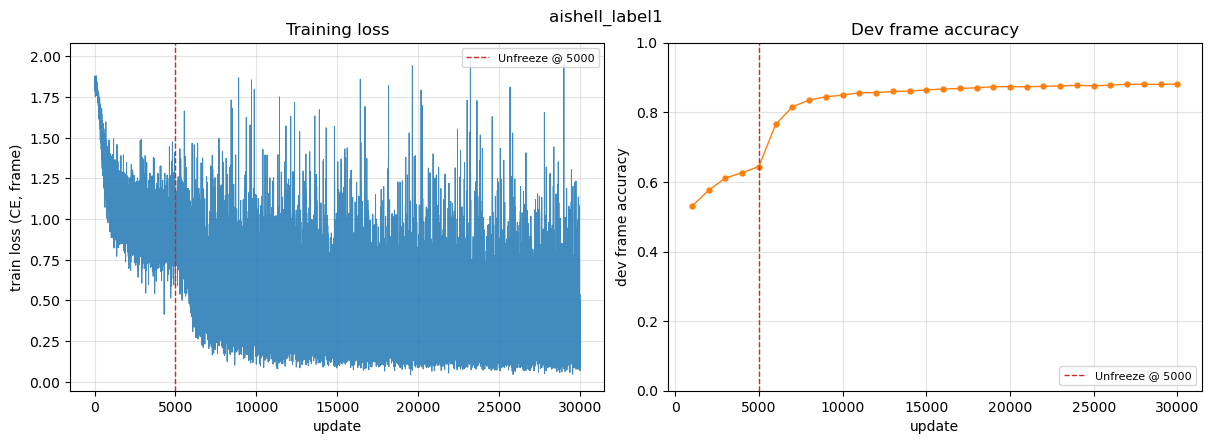

Wrote /home/huy/207177/output/checkpoint/exp_label2_ce/training_curves.png


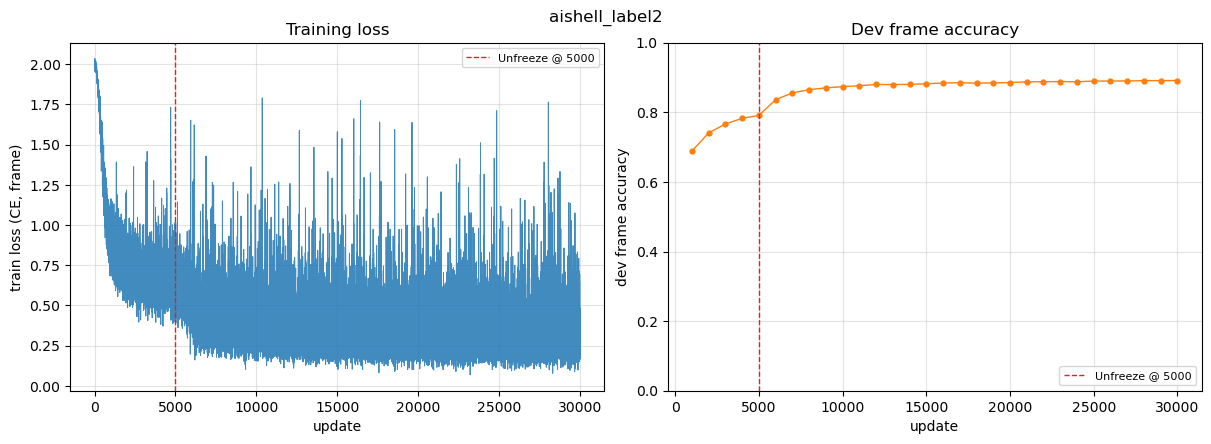

Wrote /home/huy/207177/output/checkpoint/exp_label3_ce/training_curves.png


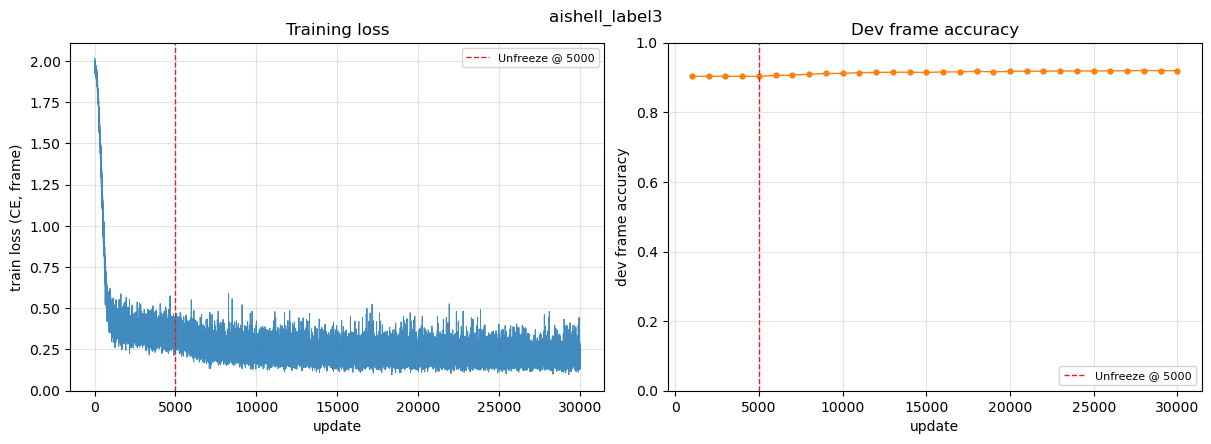

In [7]:
import matplotlib.pyplot as plt

def plot_w2v_training_curves(curves: dict = None, save_dir: Path = None, save_fig: bool = True) -> None:
    
    if curves is None and save_dir is not None:
        p = save_dir / 'training_curves.json'
        if not p.is_file():
            print('No curves file:', p)
            return
        with p.open('r', encoding='utf-8') as f:
            curves = json.load(f)
    if curves is None:
        print('No curves provided.')
        return

    t_step = curves.get('train_step', [])
    t_loss = curves.get('train_loss', [])
    d_step = curves.get('dev_step', [])
    d_acc = curves.get('dev_acc', [])
    fu = curves.get('freeze_updates', FREEZE_UPDATES)
    tag = curves.get('exp_tag', 'aishell')

    if not t_step and not d_step:
        print('No curve data in dict.')
        return

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
    if t_step and t_loss:
        ax0.plot(t_step, t_loss, color='C0', lw=0.7, alpha=0.85)
    ax0.axvline(fu, color='C3', ls='--', lw=1.0, label=f'Unfreeze @ {fu}')
    ax0.set_xlabel('update')
    ax0.set_ylabel('train loss (CE, frame)')
    ax0.set_title('Training loss')
    ax0.grid(True, alpha=0.35)
    ax0.legend(loc='upper right', fontsize=8)

    if d_step and d_acc:
        ax1.plot(d_step, d_acc, color='C1', marker='o', ms=3.5, lw=1.0)
    ax1.axvline(fu, color='C3', ls='--', lw=1.0, label=f'Unfreeze @ {fu}')
    ax1.set_xlabel('update')
    ax1.set_ylabel('dev frame accuracy')
    ax1.set_title('Dev frame accuracy')
    ax1.set_ylim(0, 1.0)
    ax1.grid(True, alpha=0.35)
    ax1.legend(loc='lower right', fontsize=8)

    fig.suptitle(tag, y=1.02)
    if save_fig and save_dir is not None:
        out = save_dir / 'training_curves.png'
        fig.savefig(out, dpi=150, bbox_inches='tight')
        print('Wrote', out)
    plt.show()

_all_curves = globals().get('all_curves', {})
for suffix in ['label1', 'label2', 'label3']:
    save_dir = CHECKPOINT_ROOT / f'exp_{suffix}_ce'
    plot_w2v_training_curves(curves=_all_curves.get(suffix), save_dir=save_dir, save_fig=True)

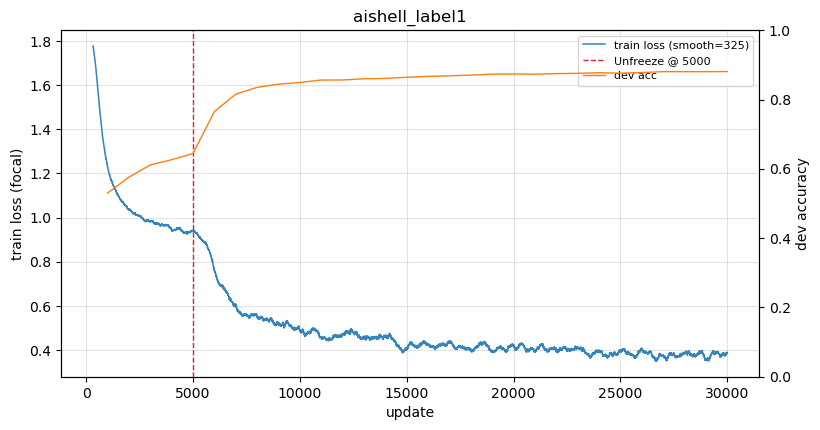

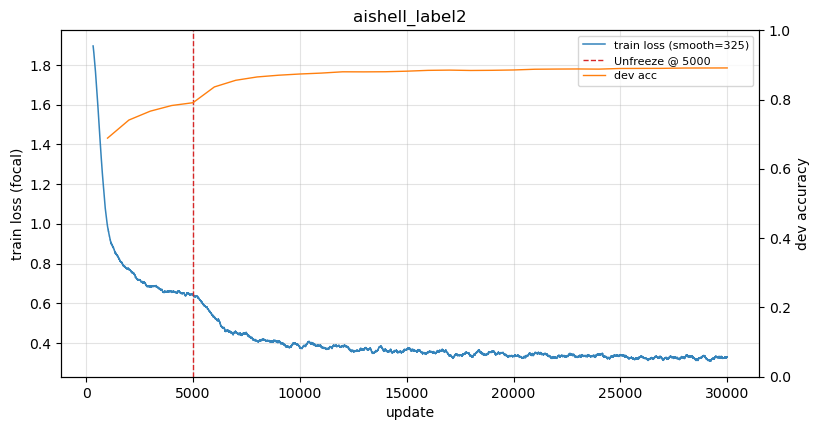

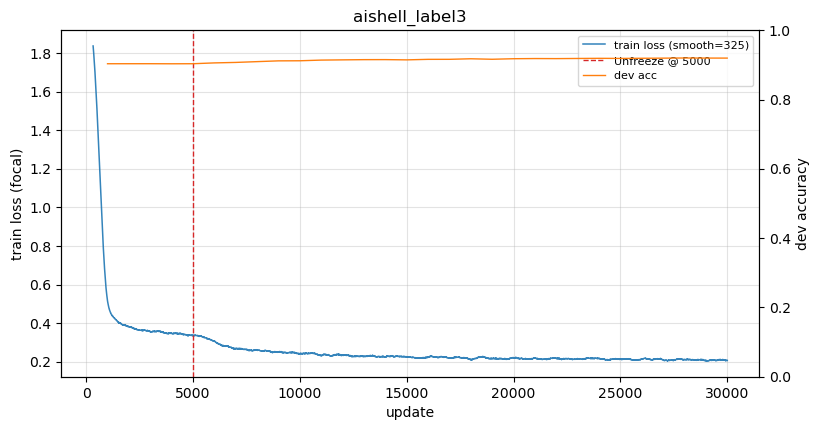

In [8]:

import matplotlib.pyplot as plt
import numpy as np

def _smooth_curve(values, window: int = 25):
    if len(values) < 3 or window <= 1:
        return values
    window = min(window, len(values))
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")

def _local_minima(xs, ys):
    if len(ys) < 3:
        return [], []
    min_x = []
    min_y = []
    for i in range(1, len(ys) - 1):
        if ys[i] < ys[i - 1] and ys[i] <= ys[i + 1]:
            min_x.append(xs[i])
            min_y.append(ys[i])
    return min_x, min_y

def plot_loss_and_accuracy(curves: dict = None, smooth_window: int = 25, save_dir: Path = None, exp_tag: str = None) -> None:
    if curves is None:
        p = save_dir / "training_curves.json"
        if not p.is_file():
            print("No in-memory history and no file:", p)
            return
        with p.open("r", encoding="utf-8") as f:
            curves = json.load(f)

    t_step = curves.get("train_step", [])
    t_loss = curves.get("train_loss", [])
    d_step = curves.get("dev_step", [])
    d_acc = curves.get("dev_acc", [])
    fu = curves.get("freeze_updates", FREEZE_UPDATES)
    tag = curves.get("exp_tag", exp_tag or "aishell")

    if not t_step and not d_step:
        print("No curve data in dict.")
        return

    fig, ax1 = plt.subplots(figsize=(9, 4.5))
    if t_step and t_loss:
        t_loss_sm = _smooth_curve(t_loss, window=smooth_window)
        t_step_sm = t_step[len(t_step) - len(t_loss_sm):]
        ax1.plot(t_step_sm, t_loss_sm, color="C0", lw=1.1, alpha=0.9, label=f"train loss (smooth={smooth_window})")
        
    ax1.set_xlabel("update")
    ax1.set_ylabel("train loss (focal)")
    ax1.grid(True, alpha=0.35)
    ax1.axvline(fu, color="C3", ls="--", lw=1.0, label=f"Unfreeze @ {fu}")

    ax2 = ax1.twinx()
    if d_step and d_acc:
        ax2.plot(d_step, d_acc, color="C1", ms=3.2, lw=1.0, label="dev acc")
    ax2.set_ylabel("dev accuracy")
    ax2.set_ylim(0, 1.0)

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper right", fontsize=8)
    ax1.set_title(tag)
    plt.show()

_all_curves = globals().get('all_curves', {})
for suffix in ['label1', 'label2', 'label3']:
    save_dir = CHECKPOINT_ROOT / f'exp_{suffix}_ce'
    plot_loss_and_accuracy(curves=_all_curves.get(suffix), smooth_window=325, save_dir=save_dir, exp_tag=f'aishell_{suffix}')